# DeepHalo Featureless Model - Example Usage

This notebook demonstrates how to use the **DeepHaloFeatureless** custom model that has been added to the choice-learn library.

The DeepHalo Featureless model is a ResNet-like neural network for discrete choice modeling that operates purely on item availability masks without requiring item or customer features. It uses residual blocks (Quadratic and Exact) to learn complex choice patterns especially those with halo effects (item-item interactions). 

## Overview
- Load synthetic choice data
- Create ChoiceDataset
- Train DeepHaloFeatureless model
- Evaluate and visualize results

## 1. Import Required Libraries

In [1]:
import sys

sys.path.append("../../")

import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt

from choice_learn.data import ChoiceDataset
from choice_learn.models import DeepHaloFeatureless

print(f"TensorFlow version: {tf.__version__}")
print(f"NumPy version: {np.__version__}")
print(f"Pandas version: {pd.__version__}")

2026-01-20 16:59:08.097448: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-01-20 16:59:08.415122: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-01-20 16:59:14.087106: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


TensorFlow version: 2.20.0
NumPy version: 2.2.6
Pandas version: 2.3.3


## 2. Load Synthetic Choice Data

We'll use the synthetic dataset that was generated with:
- 20 products in the universe
- Choice sets of fixed size 15
- 1,240,320 training samples
- 310,080 test samples

In [2]:
# Load data
data_dir = '../../../data' # Adjust the path as necessary
df_train = pd.read_csv(f'{data_dir}/Synthetic_20-15-80_Train.csv')
df_test = pd.read_csv(f'{data_dir}/Synthetic_20-15-20_Test.csv')

print(f"Train dataset shape: {df_train.shape}")
print(f"Test dataset shape: {df_test.shape}")
print(f"\nFirst few rows:")
df_train.head(3)

Train dataset shape: (1240320, 40)
Test dataset shape: (310080, 40)

First few rows:


,X0,X1,X2,X3,X4,X5,X6,X7,X8,X9,...,Y10,Y11,Y12,Y13,Y14,Y15,Y16,Y17,Y18,Y19
0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


## 3. Prepare Data for ChoiceDataset

Extract features:
- **X columns**: Availability mask (which items are in the choice set)
- **Y columns**: Actual choice (one-hot encoded)

In [3]:
n_items = 20

# Extract availability masks (X columns)
X_train = df_train[[f'X{i}' for i in range(n_items)]].values
X_test = df_test[[f'X{i}' for i in range(n_items)]].values

# Extract choices (Y columns) and convert to indices
Y_train = df_train[[f'Y{i}' for i in range(n_items)]].values
Y_test = df_test[[f'Y{i}' for i in range(n_items)]].values

y_train = np.argmax(Y_train, axis=1)
y_test = np.argmax(Y_test, axis=1)

print(f"X_train shape: {X_train.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"\nExample:")
print(f"  Availability mask: {X_train[0]}")
print(f"  Number of available items: {X_train[0].sum()}")
print(f"  Chosen item index: {y_train[0]}")

X_train shape: (1240320, 20)
y_train shape: (1240320,)

Example:
  Availability mask: [1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 0. 0. 0. 0. 0.]
  Number of available items: 15.0
  Chosen item index: 5


## 4. Create ChoiceDataset Objects

For the featureless model, we use the availability mask as the only input feature.

In [4]:
# Use a subset of the data for faster training in this example
# Remove these lines to use full dataset
n_train = min(500, len(X_train))
n_test = min(100, len(X_test))

X_train_subset = X_train[:n_train]
y_train_subset = y_train[:n_train]
X_test_subset = X_test[:n_test]
y_test_subset = y_test[:n_test]

print(f"Using {n_train} training samples and {n_test} test samples")

# Reshape availability to add feature dimension: (batch, items) -> (batch, items, 1)
X_train_reshaped = X_train_subset[:, :, np.newaxis]
X_test_reshaped = X_test_subset[:, :, np.newaxis]

print(f"Reshaped X_train: {X_train_reshaped.shape}")
print(f"Reshaped X_test: {X_test_reshaped.shape}")

# Create ChoiceDataset
dataset_train = ChoiceDataset(
    items_features_by_choice=X_train_reshaped,
    available_items_by_choice=X_train_subset.astype(int),
    choices=y_train_subset,
    shared_features_by_choice=(),
    items_features_by_choice_names=["availability"],
)

dataset_test = ChoiceDataset(
    items_features_by_choice=X_test_reshaped,
    available_items_by_choice=X_test_subset.astype(int),
    choices=y_test_subset,
    shared_features_by_choice=(),
    items_features_by_choice_names=["availability"],
)

print(f"\nTrain ChoiceDataset: {len(dataset_train)} choices")
print(f"Test ChoiceDataset: {len(dataset_test)} choices")
print(f"Number of items: {dataset_train.get_n_items()}")

                                    fit models needing them such as Conditional Logit.
                                    fit models needing them such as Conditional Logit.


Using 500 training samples and 100 test samples
Reshaped X_train: (500, 20, 1)
Reshaped X_test: (100, 20, 1)

Train ChoiceDataset: 500 choices
Test ChoiceDataset: 100 choices
Number of items: 20


## 5. Initialize DeepHaloFeatureless Model

Configure the model architecture:
- **depth**: Number of layers (5 = 1 input + 4 residual blocks + 1 output)
- **hidden_dim**: Width of internal layers (218)
- **block_types**: Type of each residual block ('qua' for quadratic, 'exa' for exact)

In [6]:
model = DeepHaloFeatureless(
    # n_items=20, # you could specify this manually, otherwise inferred from data
    depth=5,  # 4 residual blocks
    hidden_dim=218,
    block_types=['qua']*(5-1),  # All quadratic blocks
    epochs=150,
)

print(f"Model initialized successfully!")
print(f"\nModel configuration:")
print(f"  - Input size: {dataset_train.get_n_items()}")
print(f"  - Depth: {model.depth}")
print(f"  - Hidden width: {model.hidden_dim}")
print(f"  - Block types: {model.block_types}")

Using MSE loss for DeepHalo featureless discrete choice model. 
Model initialized successfully!

Model configuration:
  - Input size: 20
  - Depth: 5
  - Hidden width: 218
  - Block types: ['qua', 'qua', 'qua', 'qua']


I0000 00:00:1768928405.825333 1506486 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15502 MB memory:  -> device: 0, name: Tesla V100-SXM2-32GB, pci bus id: 0000:18:00.0, compute capability: 7.0
I0000 00:00:1768928405.836978 1506486 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 6498 MB memory:  -> device: 1, name: Tesla V100-SXM2-32GB, pci bus id: 0000:3b:00.0, compute capability: 7.0
I0000 00:00:1768928405.858121 1506486 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:2 with 9598 MB memory:  -> device: 2, name: Tesla V100-SXM2-32GB, pci bus id: 0000:86:00.0, compute capability: 7.0
I0000 00:00:1768928405.886441 1506486 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:3 with 6266 MB memory:  -> device: 3, name: Tesla V100-SXM2-32GB, pci bus id: 0000:af:00.0, compute capability: 7.0


## 6. Train the Model

In [7]:
print("Training the model...")
history = model.fit(dataset_train)

print("\nTraining completed!")
print(f"Final training loss: {history['train_loss'][-1]:.4f}")

Training the model...
DeepHaloFeatureless instantiated with n_items=20 inferred from data.


Epoch 149 Train Loss 0.0447: 100%|██████████| 150/150 [00:09<00:00, 16.07it/s]


Training completed!
Final training loss: 0.0447


## 7. Visualize Training Progress

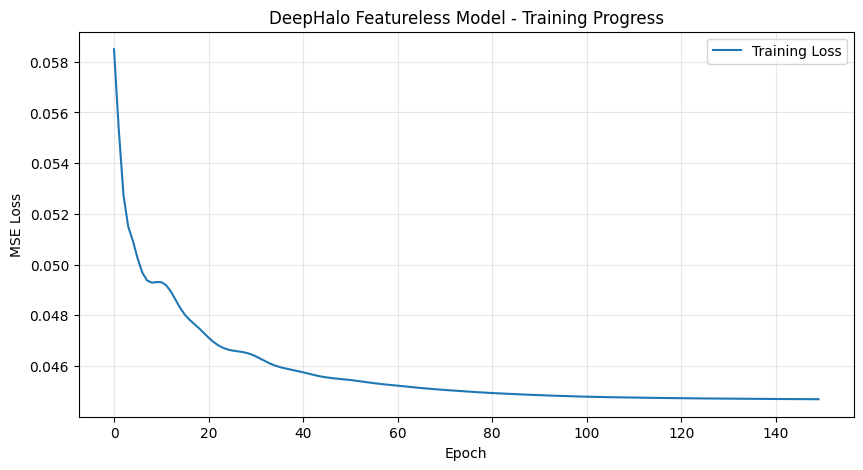

In [8]:
plt.figure(figsize=(10, 5))
plt.plot(history['train_loss'], label='Training Loss')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.title('DeepHalo Featureless Model - Training Progress')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## 8. Evaluate on Test Set

In [9]:
test_mse = model.evaluate(dataset_test)
print(f"Test Mean Squared Error: {test_mse:.4f}")

# Calculate accuracy
predictions = model.predict_probas(dataset_test)
predicted_choices = np.argmax(predictions, axis=1)
accuracy = (predicted_choices == y_test_subset).mean()
print(f"Test Accuracy: {accuracy:.4f}")

Test Mean Squared Error: 2.5259
Test Accuracy: 0.1100


## 9. Save and Load the Model

``` python
model.save_model("saved_model/")
loaded_model = DeepHaloFeatureless.load_model("saved_model/")
```